# 01 — Data Exploration

Plot processed GeoTIFF tiles alongside their ground-truth YOLO OBB labels.
All logic is imported from ; this notebook contains no business logic.

In [18]:
# ── Standard library ──────────────────────────────────────────────────────
import sys
from pathlib import Path

# Add project root to path so  is importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

# ── Third-party ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import rasterio
from matplotlib.collections import PatchCollection

# ── Project ───────────────────────────────────────────────────────────────
from src.vessels_detect.utils.config import load_config

from src.vessels_detect.utils.config import load_config
from src.vessels_detect.evaluation.metrics import (

    build_size_dataframe,
    parse_label_file,
    count_split_labels

)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Imports OK.")

Imports OK.


## 1. Configuration

Change the paths below to match your environment.

In [19]:
cfg          = load_config("../configs/data_prep.yaml")
PROCESSED    = Path("../data/processed")

TILE_SIZE    = cfg.tiling.tile_size   # pixels (pre-upsample)

# --- Configuration ---
LABELS_ROOT   = PROCESSED/ "labels"
LABELS_DIR   = PROCESSED / "labels" / "train"
IMAGES_DIR    = PROCESSED / "images" / "train"
SPLIT         = ["train", "val", "test"]

# Class names from the dataset yaml
import yaml
with open("../data/dataset.yaml") as f:
    _ds = yaml.safe_load(f)
CLASS_NAMES = _ds["names"]   # dict  {0: "Pirogue", 1: ..., }

print(f"Images dir : {IMAGES_DIR}")
print(f"Labels dir : {LABELS_ROOT}")
print(f"Tile size  : {TILE_SIZE} px")
print(f"Classes    : {CLASS_NAMES}")

Images dir : ../data/processed/images/train
Labels dir : ../data/processed/labels
Tile size  : 320 px
Classes    : {0: 'Pirogue', 1: 'Double_hulled_Pirogue', 2: 'Small_Motorboat', 3: 'Medium_Motorboat', 4: 'Large_Motorboat', 5: 'Sailing_Boat'}


## 2. Dataset Statistics

Per-class annotation counts across all splits.

In [20]:
from src.vessels_detect.evaluation.metrics import build_distribution_dataframe

df_dist = build_distribution_dataframe(
    LABELS_ROOT,
    SPLIT,
    class_names=CLASS_NAMES,
)

print("Object counts per class and split:")
display(df_dist)

classes = list(CLASS_NAMES.values())
x, width = np.arange(len(classes)), 0.25



Object counts per class and split:


,Class,Train,Val,Test,Total
0,Pirogue,976,156,228,1360
1,Double_hulled_Pirogue,817,270,118,1205
2,Small_Motorboat,473,40,60,573
3,Medium_Motorboat,221,0,41,262
4,Large_Motorboat,63,0,0,63
5,Sailing_Boat,168,13,15,196


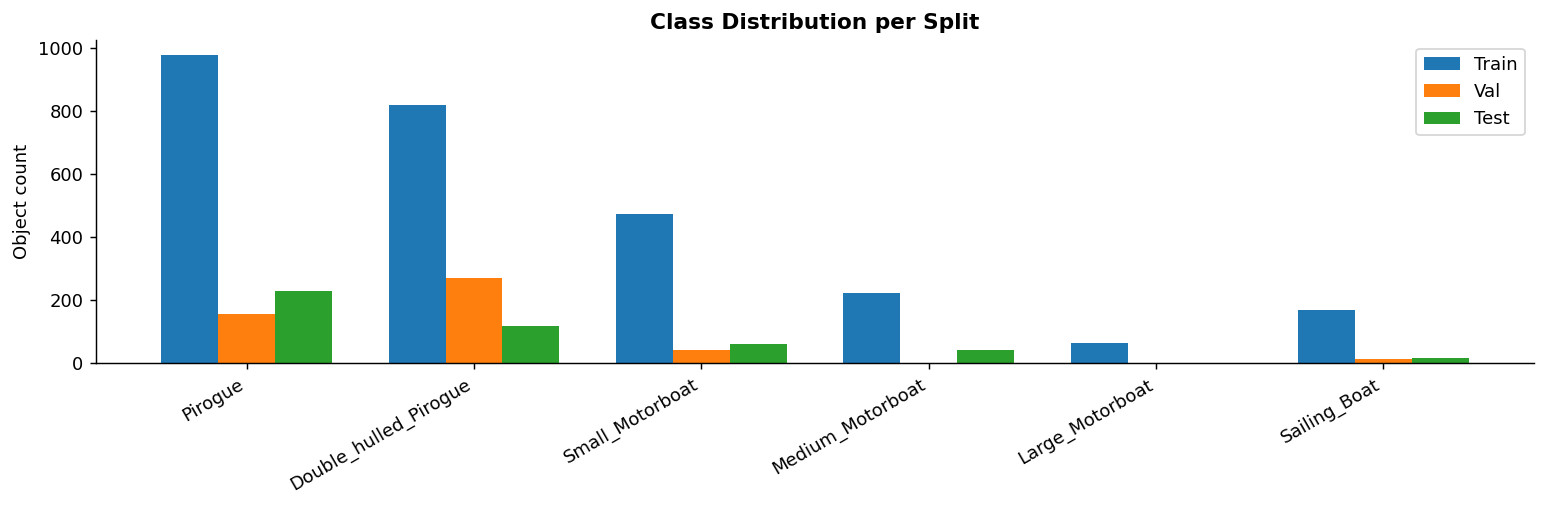

In [21]:
# Bar chart
splits   = SPLIT
classes  = list(CLASS_NAMES.values())
x        = np.arange(len(classes))
width    = 0.25

fig, ax = plt.subplots(figsize=(12, 4))
for i, split in enumerate(splits):
    vals = df_dist[split.capitalize()].values if split.capitalize() in df_dist else [0]*len(classes)
    ax.bar(x + i * width, vals, width, label=split.capitalize())

ax.set_xticks(x + width)
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.set_ylabel("Object count")
ax.set_title("Class Distribution per Split", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Tile Viewer

Display a random sample of annotated tiles with OBB overlays.
Each colour corresponds to one class.

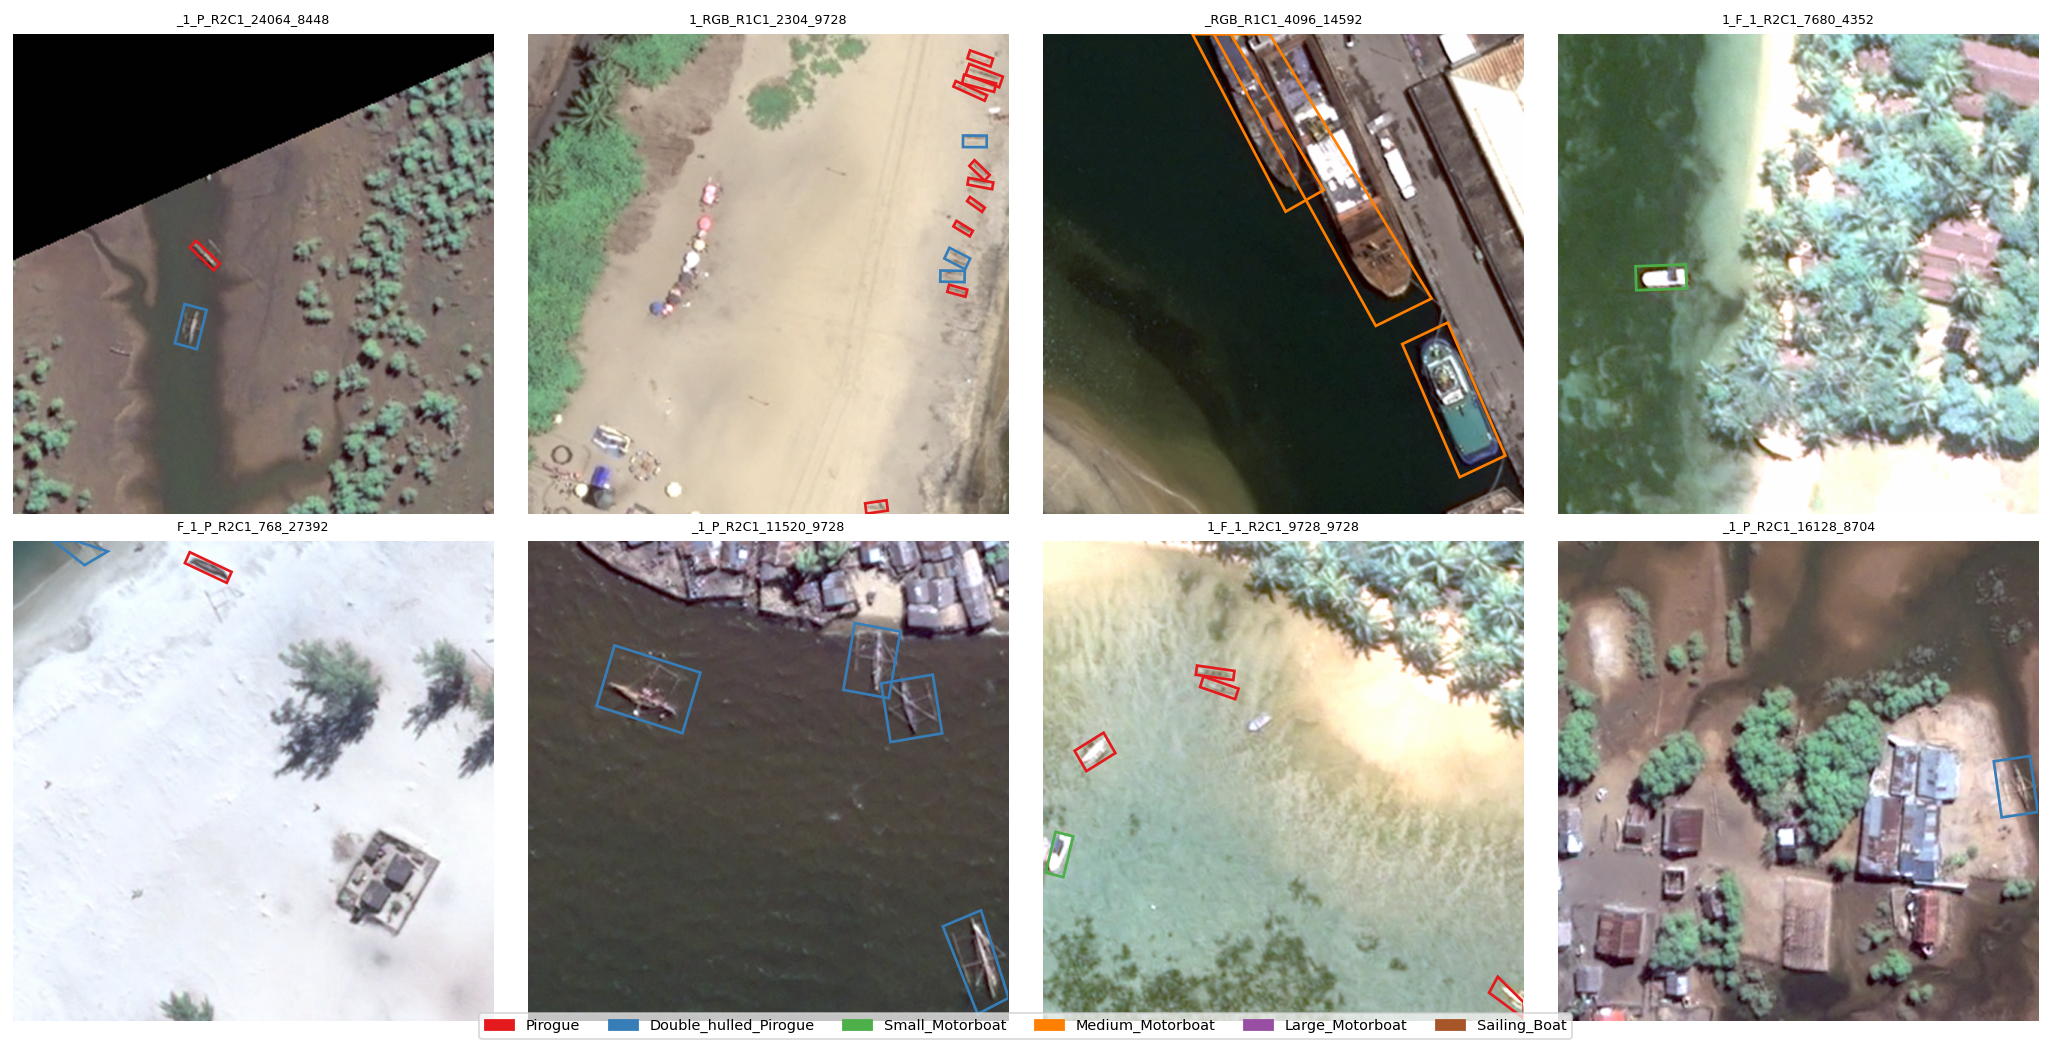

In [22]:
import random

CLASS_COLORS = {
    0: "#e41a1c", 1: "#377eb8", 2: "#4daf4a",
    3: "#ff7f00", 4: "#984ea3", 5: "#a65628",
}

def read_geotiff_as_rgb(path: Path) -> np.ndarray:
    """Read a GeoTIFF tile and return a (H, W, 3) uint8 array."""
    with rasterio.open(path) as ds:
        data = ds.read()          # (C, H, W)
    # Always return exactly 3 channels for display.
    if data.shape[0] >= 3:
        img = data[:3].transpose(1, 2, 0)
    else:
        img = np.repeat(data[:1].transpose(1, 2, 0), 3, axis=2)
    return img.astype(np.uint8)


def plot_tiles(tile_paths, labels_dir, class_names, tile_size, n_cols=4):
    n = len(tile_paths)
    if n == 0:
        print("No tiles to plot.")
        return
        
    n_rows = (n + n_cols - 1) // n_cols
    n_cols = min(n, n_cols) # Adjust columns if we have fewer images than n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    
    # Ensure axes is a flat array even if there's only 1 row/col
    if n == 1:
        axes = [axes]
    else:
        axes = np.array(axes).flatten()

    for ax, tp in zip(axes, tile_paths):
        img = read_geotiff_as_rgb(tp)
        h, w = img.shape[:2]
        ax.imshow(img)

        lbl_path = labels_dir / (tp.stem + ".txt")
        boxes = parse_label_file(lbl_path, w, h)
        for cid, pts in boxes:
            color = CLASS_COLORS.get(cid, "yellow")
            poly  = plt.Polygon(pts, fill=False, edgecolor=color, linewidth=1.5)
            ax.add_patch(poly)

        ax.set_title(tp.stem[-20:], fontsize=7)
        ax.axis("off")
        
    # Hide any remaining unused subplots if n isn't a perfect multiple of n_cols
    for i in range(n, len(axes)):
        axes[i].axis("off")

    legend_handles = [
        mpatches.Patch(color=CLASS_COLORS.get(cid, "yellow"), label=name)
        for cid, name in class_names.items()
    ]
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=len(class_names), fontsize=8, framealpha=0.7)
    plt.tight_layout()
    plt.show()


# Sample N annotated tiles
# Check for both .tif and .tiff extensions just in case
all_tiles = sorted(IMAGES_DIR.glob("*.tif")) + sorted(IMAGES_DIR.glob("*.tiff"))

if not all_tiles:
    print(f"No images found in {IMAGES_DIR}. Please check your path and file extensions.")
else:
    anno_tiles = [
        t for t in all_tiles
        if (LABELS_DIR / (t.stem + ".txt")).exists()
        and (LABELS_DIR / (t.stem + ".txt")).stat().st_size > 0
    ]
    
    if not anno_tiles:
        print(f"Images found, but no matching non-empty label files were found in {LABELS_DIR}.")
    else:
        sample = random.sample(anno_tiles, min(8, len(anno_tiles)))
        plot_tiles(sample, LABELS_DIR, CLASS_NAMES, TILE_SIZE)

## 4. OBB Geometric Statistics

Long side, short side, area, and aspect ratio per class across all splits.

,Class ID,Class,Count,Long mean (px),Long std,Short mean (px),Short std,Area mean (px²),Aspect ratio
0,0,Pirogue,1360,22.38,8.03,6.45,2.73,157.72,6.364903e+07
1,1,Double_hulled_Pirogue,1205,35.78,13.04,18.61,7.58,728.47,5.909701e+07
2,2,Small_Motorboat,573,35.64,12.48,12.34,4.45,469.91,3.150000e+00
3,3,Medium_Motorboat,262,99.09,45.69,22.66,13.03,2646.77,4.546031e+09
4,4,Large_Motorboat,63,196.97,107.70,48.99,38.85,14454.77,1.017307e+10
5,5,Sailing_Boat,196,57.58,20.98,15.65,6.57,930.43,4.602446e+08


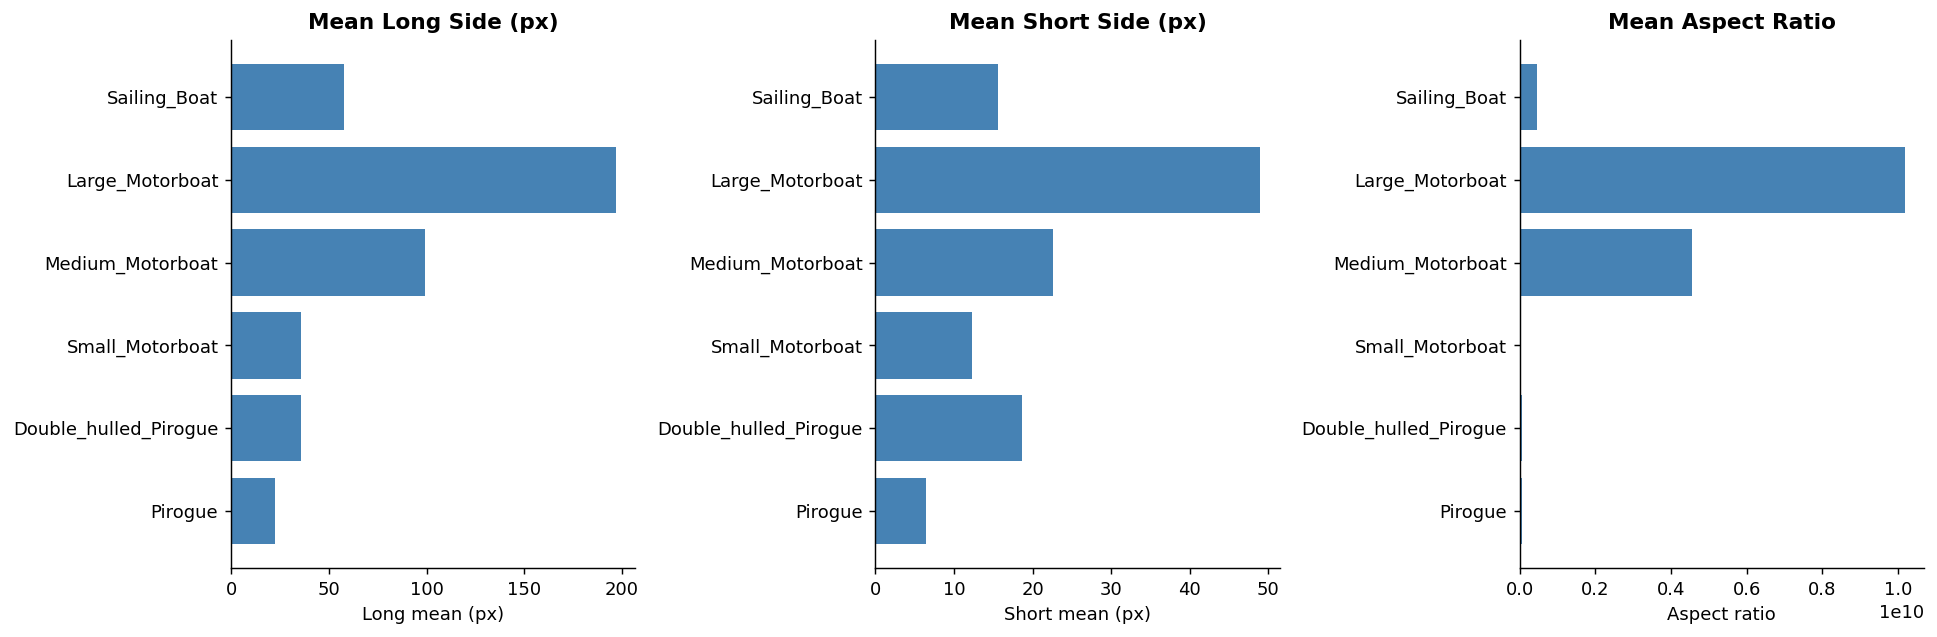

In [26]:
df_sizes = build_size_dataframe(LABELS_ROOT, SPLIT, CLASS_NAMES, tile_size=TILE_SIZE)
display(df_sizes)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(
    axes,
    ["Long mean (px)", "Short mean (px)", "Aspect ratio"],
    ["Mean Long Side (px)", "Mean Short Side (px)", "Mean Aspect Ratio"],
):
    ax.barh(df_sizes["Class"], df_sizes[col], color="steelblue")
    ax.set_xlabel(col); ax.set_title(title, fontweight="bold")

plt.tight_layout(); plt.show()